In [1]:
import numpy as np
from sklearn.utils import shuffle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import umap
import pandas as pd
from numpy import inf
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_score
from joblib import Parallel, delayed

/opt/miniconda3/envs/your_env_name/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import opfython.math.general as g
import opfython.stream.parser as p
import opfython.stream.splitter as s
from opfython.models import SupervisedOPF
from opfython.stream import loader
from opfython.utils import logging

Load Dataset

In [3]:
df_cis = pd.read_csv('../data/cis_data.csv')
df_cacao = pd.read_csv(r'../data/data_temp/cacao.csv')
df_algarrobo = pd.read_csv(r'../data/data_temp/algarrobo.csv')
df_fruits_pures = pd.read_csv(r'../data/data_temp/MIR_Fruit_purees.csv')
df_fresh_meat = pd.read_csv(r'../data/data_temp/Fresh_meats.csv')
df_olive = pd.read_csv(r'../data/data_temp/Olive_Oils_Quadrum.csv')


df_x_cacao = df_cacao.iloc[:, 1:]
y_cacao = df_cacao.iloc[:, 0:1]
X_cacao = (df_x_cacao-df_x_cacao.min())/(df_x_cacao.max()-df_x_cacao.min())

unique_names_algarrobo = df_algarrobo['Labels'].unique()
algarrobo_x = df_algarrobo.loc[:, 'R':'REDVI']
y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
X_algarrobo = (algarrobo_x-algarrobo_x.min())/(algarrobo_x.max()-algarrobo_x.min())

cis_x = df_cis[['X', 'Y', 'X10', 'Y10', 'X20', 'Y20', 'X30', 'Y30', 'X40', 'Y40']]
y_cis = df_cis[['Result']]




unique_names_berry = df_fruits_pures["label"].unique()
fruits_pures_x = df_fruits_pures.iloc[:,1:]
y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
X_fruit_puree = (fruits_pures_x-fruits_pures_x.min())/(fruits_pures_x.max()-fruits_pures_x.min())


unique_names_meat = df_fresh_meat["meat"].unique()
meat_x = df_fresh_meat.iloc[:,4:]
y_meat = df_fresh_meat.iloc[:,0:1].replace(to_replace=unique_names_meat,value=range(0,len(unique_names_meat)))
X_meat =  (meat_x-meat_x.min())/(meat_x.max()-meat_x.min())

unique_names_olive = df_olive["Provenance"].unique()
olive_x = df_olive.iloc[:,3:]
y_olive = df_olive.iloc[:,2:3].replace(to_replace=unique_names_olive,value=range(0,len(unique_names_olive)))
X_olive =  (olive_x-olive_x.min())/(olive_x.max()-olive_x.min())

X_cis = (cis_x-cis_x.min())/(cis_x.max()-cis_x.min())
covering_array  = np.loadtxt(r'../data/coveringArray.csv', delimiter=",", dtype=int)



/var/folders/7w/w1_t98cs0k13zhwgxq2zvwj40000gn/T/ipykernel_993/664055271.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_algarrobo = df_algarrobo['Labels'].replace(to_replace=['N', 'P'], value=[0, 1])
/var/folders/7w/w1_t98cs0k13zhwgxq2zvwj40000gn/T/ipykernel_993/664055271.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fruit_puree = df_fruits_pures.iloc[:,0:1].replace(to_replace=unique_names_berry, value =range(0,len(unique_names_berry)))
/var/folders/7w/w1_t98cs0k13zhwgxq2zvwj40000gn/T/ipykernel_993/664055271.py:32

In [4]:

def cafs(ca,dataset_x,dataset_y, max_iter ,clasifier,print_logs=False):

  global_max = 0
  max_iteartion = 0
  num_rows = ca.shape[0]
  global_data_set = dataset_x.columns.values.copy()

  result_list_x = []
  result_list_y = []
  result_list_score = []
  result_list_std = []

  if len(dataset_x.columns) < ca.shape[1] :
    num_colums = len(dataset_x.columns)
  else:
    num_colums = ca.shape[1]

  initialTestTraining(result_list_score,result_list_x, result_list_y,dataset_x, dataset_y,result_list_std,clasifier)
  while max_iteartion < max_iter:

     
     max_score = 0.0
     best_std = 0
     mx_data_set = None
     lst_of_subsets_to_run = []
     lst_headers = global_data_set.copy()
    
     for i in range(0,num_rows):
        lst_headers_to_select = []
        for j in range(0,num_colums ):
          if ca[i][j] == 1 :
              lst_headers_to_select.append(lst_headers[j])
        if len(lst_headers_to_select) == 0:
            continue
        #df_temp = dataset_x[lst_headers_to_select]
        lst_of_subsets_to_run.append((lst_headers_to_select,i))
        #cross_val_score(clasifier,df_temp.values, dataset_y.values.ravel(), cv=5, scoring='f1_macro',n_jobs=-1)
     
     results = Parallel(n_jobs=-1)(delayed(run_cv)(clasifier, dataset_x, subset_features, dataset_y.values.ravel(), i) for subset_features,i in lst_of_subsets_to_run)
     sorted_results = sorted(results, key=lambda x: x[2])
     for score, std, i, subset_features in sorted_results:
        if score >= max_score:
              max_score = score
              best_std = std
              mx_data_set = subset_features.copy()
              
     global_data_set = mx_data_set.copy()
     global_max = max_score
     if print_logs:
         print(f"best f1 score= {global_max}, iteration:{max_iteartion}, numbers features selected ={len(global_data_set)},best features selected={', '.join(global_data_set)}" )

     num_colums  = len(global_data_set)
     mx_data_set = None
     max_score = 0
     max_iteartion = max_iteartion  +1

     result_list_x.append(max_iteartion)
     result_list_y.append(len(global_data_set))
     result_list_score.append(global_max)
     result_list_std.append(best_std)
     
  return result_list_x,result_list_y,result_list_score,result_list_std

def initialTestTraining(score_list, iter_list, feature_list ,X,y,result_list_std,clasifier):
    score = cross_val_score(clasifier,X, y.values.ravel(), cv=5, scoring='f1_macro',n_jobs=-1)
    score_list.append(score.mean())
    feature_list.append(X.shape[1])
    iter_list.append(0)
    result_list_std.append(score.std())

def run_cv(model, X, subset_features, y, index):
    scores = cross_val_score(model, X[subset_features].values, y, cv=5, scoring='f1_macro',n_jobs=1)
    return (scores.mean(), scores.std(), index, subset_features)


In [5]:

from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler


def plot_original_vs_reduced_umap(df_reduced_dataset,df_complete, y_dataset_integer,unique_classes):
    umap_3d = umap.UMAP(n_components=3)
    
    X_reduced_standarized = StandardScaler().fit_transform(df_reduced_dataset)
    X_complete_standarized  = StandardScaler().fit_transform(df_complete)
    
    reduced_umap = umap_3d.fit_transform(X_reduced_standarized)
    complete_umap = umap_3d.fit_transform(X_complete_standarized)
  
    fig = plt.figure(figsize=plt.figaspect(0.5))
    y_dataset_flatten = y_dataset_integer.values.ravel()

    print(unique_classes)
    ax = fig.add_subplot(1, 2, 1, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(complete_umap[indices,0], complete_umap[indices,1], complete_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])
    plt.legend()
    #ax.scatter(complete_umap[:,0], complete_umap[:,1], complete_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    
    ax = fig.add_subplot(1, 2, 2, projection='3d')
    for i in range(0,len(unique_classes)): 
        indices = np.where(y_dataset_flatten == i)
        ax.scatter(reduced_umap[indices,0], reduced_umap[indices,1], reduced_umap[indices,2], c=sns.color_palette()[i],marker = "v", label=unique_classes[i])

    #ax.scatter(reduced_umap[:,0], reduced_umap[:,1], reduced_umap[:,2], c=[sns.color_palette()[x] for x in y_dataset_flatten],marker = "v",label=unique_classes[0])
    plt.legend()
    
    plt.show()
   

In [6]:
def  plot_results_for_covering_array(scores,feature,num_of_iterarion, path_to_save_image):
        color = 'tab:blue'
        res_scores = np.array(scores)
        res_features = np.array(feature)
        res_iter = np.array(num_of_iterarion)

        plt.figure(figsize=(11, 10))
        
        fig, ax1 = plt.subplots()
        barwidth = 0.4
        color = 'tab:red'
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Number of features', color=color)
        #ax1.set_title("ICAFS Feature selection on the Cacao dataset")
        ax1.spines['top'].set_visible(False)
        ax1.bar(res_iter-0.2, res_features, color=color, width=barwidth)
        ax1.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax1.set_ylim(1,max(res_features)+3)
        ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
        #for i in range(len(res_iter)):
        #    ax1.text(i+1-0.2,    res_features[i], res_features[i],rotation='vertical')
        for bar in ax1.patches:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height}', fontsize=10,
                    ha='center', va='bottom', rotation=90)
            
        ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
        color = 'tab:blue'
        ax2.set_ylabel('F1_score', color=color)
        ax2.bar(res_iter+0.2, res_scores, color=color, width=barwidth)
        ax2.tick_params(axis='y', labelcolor=color,labelrotation=45)
        ax2.set_ylim(min(res_scores)-0.001, max(res_scores)+0.001)

        fig.tight_layout()  # otherwise the right y-label is slightly clipped
        #for i in range(len(res_iter)):
        #    ax2.text(i+1, res_scores[i], f"{res_scores[i]:.3f}",rotation='vertical')

        for bar in ax2.patches:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f' {height:.2f}', fontsize=10,
                    ha='center', va='bottom', rotation=90)

        #plt.title('ICAFS Feature selection for Cacao Dataset with OPF', y=-0.20)
        plt.gca().set_frame_on(False)
        plt.savefig(path_to_save_image)

# CAFS KNN

In [22]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores,stds = cafs(covering_array,X_cacao,y_cacao,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.8578955297717368, iteration:0, numbers features selected =699,best features selected=1100, 1101, 1102, 1105, 1107, 1108, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1119, 1120, 1122, 1123, 1124, 1127, 1131, 1132, 1133, 1139, 1142, 1144, 1145, 1146, 1147, 1152, 1155, 1156, 1157, 1158, 1161, 1162, 1166, 1168, 1169, 1171, 1172, 1173, 1178, 1179, 1180, 1181, 1182, 1187, 1190, 1191, 1194, 1198, 1199, 1200, 1201, 1203, 1204, 1206, 1207, 1208, 1209, 1210, 1212, 1214, 1215, 1216, 1219, 1222, 1223, 1227, 1228, 1230, 1234, 1235, 1236, 1239, 1240, 1243, 1245, 1249, 1250, 1251, 1253, 1254, 1258, 1261, 1264, 1265, 1267, 1268, 1270, 1275, 1277, 1281, 1283, 1284, 1290, 1291, 1295, 1297, 1298, 1302, 1304, 1305, 1306, 1309, 1310, 1311, 1312, 1315, 1316, 1317, 1319, 1320, 1322, 1323, 1324, 1325, 1327, 1330, 1333, 1334, 1336, 1337, 1339, 1340, 1341, 1344, 1348, 1349, 1350, 1352, 1354, 1355, 1358, 1359, 1363, 1364, 1365, 1367, 1370, 1371, 1372, 1375, 1376, 1378, 1379, 1382, 1384, 1386, 1392

In [8]:
print("CAFS KNN - Cacao Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Cacao, Std: {std:.6f}")

CAFS KNN - Cacao Dataset
Index 0: Dataset Cacao, Std: 0.052780
Index 1: Dataset Cacao, Std: 0.051795
Index 2: Dataset Cacao, Std: 0.047993
Index 3: Dataset Cacao, Std: 0.032351
Index 4: Dataset Cacao, Std: 0.036651
Index 5: Dataset Cacao, Std: 0.040891
Index 6: Dataset Cacao, Std: 0.039045
Index 7: Dataset Cacao, Std: 0.030248
Index 8: Dataset Cacao, Std: 0.027713
Index 9: Dataset Cacao, Std: 0.027713
Index 10: Dataset Cacao, Std: 0.027713


In [9]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=3)
iterarions,features,scores,stds = cafs(covering_array,X_algarrobo,y_algarrobo,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.7428937129006083, iteration:0, numbers features selected =9,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI, EVI, NDRE, RERVI
best f1 score= 0.740047443200288, iteration:1, numbers features selected =8,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI, NDRE, RERVI
best f1 score= 0.7500585634258129, iteration:2, numbers features selected =7,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI, RERVI
best f1 score= 0.7477139421526717, iteration:3, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI
best f1 score= 0.7477139421526717, iteration:4, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI
best f1 score= 0.7477139421526717, iteration:5, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, DVI
best f1 score= 0.7477139421526717, iteration:6, numbers features selected =6,best features selected=Edge Red, EXGR, VEG, RGBVI, NDVI, D

In [10]:
print("CAFS KNN - Algarrobo Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Algarrobo, Std: {std:.6f}")

CAFS KNN - Algarrobo Dataset
Index 0: Dataset Algarrobo, Std: 0.059220
Index 1: Dataset Algarrobo, Std: 0.039844
Index 2: Dataset Algarrobo, Std: 0.036747
Index 3: Dataset Algarrobo, Std: 0.025277
Index 4: Dataset Algarrobo, Std: 0.041874
Index 5: Dataset Algarrobo, Std: 0.041874
Index 6: Dataset Algarrobo, Std: 0.041874
Index 7: Dataset Algarrobo, Std: 0.041874
Index 8: Dataset Algarrobo, Std: 0.041874
Index 9: Dataset Algarrobo, Std: 0.041874
Index 10: Dataset Algarrobo, Std: 0.041874


In [11]:
#plot_original_vs_reduced_umap(X_algarrobo[['Edge Red', 'EXGR', 'VEG', 'RGBVI', 'NDVI', 'DVI']],X_algarrobo,y_algarrobo,unique_names_algarrobo)

In [12]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores,stds = cafs(covering_array,X_cis,y_cis,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9698757615292537, iteration:0, numbers features selected =6,best features selected=X, Y, X10, X20, Y30, Y40
best f1 score= 0.9843963492206788, iteration:1, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:2, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:3, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:4, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:5, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:6, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:7, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9843963492206788, iteration:8, numbers features selec

In [13]:
print("CAFS KNN - CIS Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset CIS, Std: {std:.6f}")

CAFS KNN - CIS Dataset
Index 0: Dataset CIS, Std: 0.005158
Index 1: Dataset CIS, Std: 0.004544
Index 2: Dataset CIS, Std: 0.002418
Index 3: Dataset CIS, Std: 0.002418
Index 4: Dataset CIS, Std: 0.002418
Index 5: Dataset CIS, Std: 0.002418
Index 6: Dataset CIS, Std: 0.002418
Index 7: Dataset CIS, Std: 0.002418
Index 8: Dataset CIS, Std: 0.002418
Index 9: Dataset CIS, Std: 0.002418
Index 10: Dataset CIS, Std: 0.002418


In [14]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores,stds = cafs(covering_array,X_fruit_puree,y_fruit_puree,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\fruit_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9528589993364125, iteration:0, numbers features selected =111,best features selected=910.907, 914.767, 922.487, 934.067, 941.787, 953.367, 961.087, 964.947, 980.387, 984.247, 988.107, 991.967, 999.687, 1003.547, 1007.407, 1022.847, 1038.287, 1046.007, 1049.867, 1092.327, 1115.487, 1123.207, 1134.786, 1138.646, 1142.506, 1157.946, 1161.806, 1165.666, 1173.386, 1177.246, 1184.966, 1192.686, 1196.546, 1200.406, 1204.266, 1208.126, 1219.706, 1231.286, 1235.146, 1246.726, 1254.446, 1258.306, 1266.026, 1269.886, 1281.466, 1289.186, 1296.906, 1304.626, 1312.346, 1331.646, 1339.366, 1354.806, 1358.666, 1366.386, 1370.246, 1374.106, 1377.966, 1385.686, 1404.985, 1408.845, 1412.705, 1420.425, 1432.005, 1435.865, 1447.445, 1470.605, 1474.465, 1478.325, 1486.045, 1489.905, 1493.765, 1501.485, 1505.345, 1509.205, 1513.065, 1524.645, 1528.505, 1532.365, 1543.945, 1547.805, 1555.525, 1559.385, 1563.245, 1567.105, 1574.825, 1582.545, 1586.405, 1597.985, 1609.565, 1636.585, 1640.445, 1

In [15]:
print("CAFS KNN - Fruit Puree Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Fruit Puree, Std: {std:.6f}")

CAFS KNN - Fruit Puree Dataset
Index 0: Dataset Fruit Puree, Std: 0.013042
Index 1: Dataset Fruit Puree, Std: 0.011056
Index 2: Dataset Fruit Puree, Std: 0.012055
Index 3: Dataset Fruit Puree, Std: 0.010445
Index 4: Dataset Fruit Puree, Std: 0.011669
Index 5: Dataset Fruit Puree, Std: 0.009501
Index 6: Dataset Fruit Puree, Std: 0.009124
Index 7: Dataset Fruit Puree, Std: 0.015701
Index 8: Dataset Fruit Puree, Std: 0.015701
Index 9: Dataset Fruit Puree, Std: 0.015701
Index 10: Dataset Fruit Puree, Std: 0.015701


In [16]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores,stds = cafs(covering_array,X_meat,y_meat,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\meat_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9663694366635542, iteration:0, numbers features selected =211,best features selected=1011.138, 1016.9265, 1022.715, 1024.6445, 1028.5035, 1030.433, 1034.292, 1043.9405, 1047.7995, 1051.6585, 1057.447, 1061.306, 1063.2355, 1074.8135, 1076.743, 1084.461, 1088.32, 1090.2495, 1097.9675, 1101.8265, 1103.756, 1105.6855, 1111.475, 1113.4045, 1115.334, 1117.2635, 1119.193, 1124.9815, 1128.8405, 1130.77, 1134.63, 1138.489, 1142.348, 1144.2775, 1146.207, 1148.1365, 1151.9955, 1157.784, 1163.5725, 1165.502, 1169.362, 1171.2915, 1175.1505, 1177.08, 1179.0095, 1184.798, 1192.517, 1194.4465, 1196.376, 1200.235, 1204.094, 1206.0235, 1211.812, 1213.7415, 1221.4595, 1223.389, 1225.3195, 1227.249, 1233.0375, 1234.967, 1236.8965, 1242.685, 1244.6145, 1248.4745, 1250.404, 1256.1925, 1260.0515, 1263.9105, 1275.4875, 1281.276, 1290.9245, 1292.854, 1294.7835, 1298.6425, 1300.572, 1306.3615, 1308.291, 1312.15, 1314.0795, 1316.009, 1317.9385, 1329.5155, 1331.445, 1333.3745, 1335.304, 1343.023,

In [17]:
print("CAFS KNN - Meat Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Meat, Std: {std:.6f}")

CAFS KNN - Meat Dataset
Index 0: Dataset Meat, Std: 0.041190
Index 1: Dataset Meat, Std: 0.041190
Index 2: Dataset Meat, Std: 0.041190
Index 3: Dataset Meat, Std: 0.041190
Index 4: Dataset Meat, Std: 0.041190
Index 5: Dataset Meat, Std: 0.041190
Index 6: Dataset Meat, Std: 0.041190
Index 7: Dataset Meat, Std: 0.048993
Index 8: Dataset Meat, Std: 0.048993
Index 9: Dataset Meat, Std: 0.033407
Index 10: Dataset Meat, Std: 0.033407


In [18]:
start_time = time.time()
lr_algo = KNeighborsClassifier(n_neighbors=2)
iterarions,features,scores,stds = cafs(covering_array,X_olive,y_olive,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\olive_knn_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.8988098309499237, iteration:0, numbers features selected =270,best features selected=798.892, 810.469, 816.2575, 820.1165, 822.046, 823.9755, 825.905, 835.5525, 841.341, 843.2705, 845.2, 847.1295, 852.918, 854.8475, 862.5655, 866.4245, 868.354, 872.213, 874.1425, 876.072, 885.7195, 887.649, 889.5785, 891.508, 893.4375, 903.085, 908.8735, 910.803, 916.5915, 924.3095, 926.239, 928.1685, 930.098, 933.957, 935.8865, 939.7455, 941.675, 943.6045, 945.534, 947.4645, 951.3235, 955.1825, 959.0415, 960.971, 966.7595, 972.548, 974.4775, 982.1955, 984.125, 987.984, 995.702, 997.6315, 999.561, 1005.3495, 1007.279, 1013.0675, 1016.9265, 1022.715, 1024.6445, 1026.574, 1030.433, 1032.3625, 1040.0815, 1045.87, 1051.6585, 1053.588, 1057.447, 1059.3765, 1063.2355, 1072.883, 1076.743, 1080.602, 1086.3905, 1090.2495, 1092.179, 1103.756, 1105.6855, 1113.4045, 1117.2635, 1119.193, 1126.911, 1130.77, 1132.7005, 1134.63, 1140.4185, 1142.348, 1144.2775, 1146.207, 1151.9955, 1155.8545, 1157.784,

In [19]:
print("CAFS KNN - Olive Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Olive, Std: {std:.6f}")

CAFS KNN - Olive Dataset
Index 0: Dataset Olive, Std: 0.098789
Index 1: Dataset Olive, Std: 0.093351
Index 2: Dataset Olive, Std: 0.082890
Index 3: Dataset Olive, Std: 0.077611
Index 4: Dataset Olive, Std: 0.066811
Index 5: Dataset Olive, Std: 0.066811
Index 6: Dataset Olive, Std: 0.066837
Index 7: Dataset Olive, Std: 0.076344
Index 8: Dataset Olive, Std: 0.076344
Index 9: Dataset Olive, Std: 0.076344
Index 10: Dataset Olive, Std: 0.076344


# CAFS SVC 

In [34]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores,stds = cafs(covering_array,X_cacao,y_cacao,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cacao_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.675423401366624, iteration:0, numbers features selected =699,best features selected=1101, 1102, 1103, 1104, 1106, 1108, 1109, 1113, 1116, 1123, 1124, 1126, 1128, 1129, 1131, 1132, 1136, 1138, 1139, 1140, 1141, 1142, 1148, 1151, 1152, 1154, 1156, 1159, 1160, 1164, 1167, 1168, 1169, 1170, 1171, 1172, 1173, 1174, 1175, 1176, 1178, 1179, 1180, 1181, 1182, 1184, 1187, 1189, 1190, 1193, 1194, 1196, 1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1210, 1211, 1212, 1214, 1217, 1219, 1220, 1223, 1225, 1226, 1227, 1228, 1230, 1232, 1233, 1236, 1240, 1241, 1242, 1243, 1244, 1245, 1246, 1250, 1254, 1257, 1258, 1262, 1263, 1266, 1267, 1268, 1269, 1271, 1273, 1274, 1279, 1282, 1283, 1285, 1288, 1290, 1291, 1292, 1293, 1294, 1297, 1299, 1300, 1302, 1310, 1313, 1314, 1315, 1318, 1319, 1321, 1326, 1328, 1330, 1331, 1333, 1335, 1337, 1338, 1339, 1340, 1344, 1348, 1349, 1350, 1352, 1354, 1355, 1356, 1357, 1360, 1362, 1363, 1364, 1366, 1368, 1370, 1371, 1372, 1373, 1374, 1375, 1376, 1377,

In [21]:
print("CAFS SVC - Cacao Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Cacao, Std: {std:.6f}")

CAFS SVC - Cacao Dataset
Index 0: Dataset Cacao, Std: 0.051576
Index 1: Dataset Cacao, Std: 0.050558
Index 2: Dataset Cacao, Std: 0.049110
Index 3: Dataset Cacao, Std: 0.051164
Index 4: Dataset Cacao, Std: 0.051887
Index 5: Dataset Cacao, Std: 0.046772
Index 6: Dataset Cacao, Std: 0.062618
Index 7: Dataset Cacao, Std: 0.050637
Index 8: Dataset Cacao, Std: 0.051723
Index 9: Dataset Cacao, Std: 0.051723
Index 10: Dataset Cacao, Std: 0.051723


In [22]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores,stds = cafs(covering_array,X_algarrobo,y_algarrobo,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\algarrobo_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.7472856662121755, iteration:0, numbers features selected =10,best features selected=G, B, Edge Red, NIR, EXGR, NGBDI, RGRI, VEG, NDVI, REDVI
best f1 score= 0.7516098663481436, iteration:1, numbers features selected =6,best features selected=G, Edge Red, NIR, NGBDI, RGRI, VEG
best f1 score= 0.7572140568042671, iteration:2, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:3, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:4, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:5, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:6, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 score= 0.7572140568042671, iteration:7, numbers features selected =3,best features selected=NIR, NGBDI, VEG
best f1 sco

In [23]:
print("CAFS SVC - Algarrobo Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Algarrobo, Std: {std:.6f}")

CAFS SVC - Algarrobo Dataset
Index 0: Dataset Algarrobo, Std: 0.056124
Index 1: Dataset Algarrobo, Std: 0.049782
Index 2: Dataset Algarrobo, Std: 0.040962
Index 3: Dataset Algarrobo, Std: 0.045794
Index 4: Dataset Algarrobo, Std: 0.045794
Index 5: Dataset Algarrobo, Std: 0.045794
Index 6: Dataset Algarrobo, Std: 0.045794
Index 7: Dataset Algarrobo, Std: 0.045794
Index 8: Dataset Algarrobo, Std: 0.045794
Index 9: Dataset Algarrobo, Std: 0.045794
Index 10: Dataset Algarrobo, Std: 0.045794


In [8]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores,stds = cafs(covering_array,X_cis,y_cis,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\cis_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9759851337865222, iteration:0, numbers features selected =6,best features selected=X, Y, X10, X20, Y30, Y40
best f1 score= 0.9775878322528507, iteration:1, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:2, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:3, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:4, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:5, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:6, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:7, numbers features selected =4,best features selected=X, Y, X10, Y40
best f1 score= 0.9775878322528507, iteration:8, numbers features selec

In [9]:
print("CAFS SVC - CIS Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset CIS, Std: {std:.6f}")

CAFS SVC - CIS Dataset
Index 0: Dataset CIS, Std: 0.001963
Index 1: Dataset CIS, Std: 0.004057
Index 2: Dataset CIS, Std: 0.004011
Index 3: Dataset CIS, Std: 0.004011
Index 4: Dataset CIS, Std: 0.004011
Index 5: Dataset CIS, Std: 0.004011
Index 6: Dataset CIS, Std: 0.004011
Index 7: Dataset CIS, Std: 0.004011
Index 8: Dataset CIS, Std: 0.004011
Index 9: Dataset CIS, Std: 0.004011
Index 10: Dataset CIS, Std: 0.004011


In [10]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores,stds = cafs(covering_array,X_meat,y_meat,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\meat_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9830687830687831, iteration:0, numbers features selected =237,best features selected=1005.3495, 1007.279, 1013.0675, 1014.997, 1016.9265, 1022.715, 1024.6445, 1028.5035, 1030.433, 1032.3625, 1034.292, 1038.151, 1042.011, 1043.9405, 1051.6585, 1057.447, 1070.9535, 1072.883, 1076.743, 1080.602, 1082.5315, 1086.3905, 1088.32, 1096.038, 1099.897, 1101.8265, 1103.756, 1105.6855, 1107.615, 1119.193, 1124.9815, 1126.911, 1130.77, 1134.63, 1140.4185, 1142.348, 1150.066, 1155.8545, 1157.784, 1159.7135, 1161.643, 1163.5725, 1165.502, 1167.4325, 1169.362, 1171.2915, 1173.221, 1177.08, 1179.0095, 1180.939, 1182.8685, 1184.798, 1188.657, 1194.4465, 1198.3055, 1200.235, 1206.0235, 1207.953, 1211.812, 1221.4595, 1223.389, 1225.3195, 1227.249, 1229.1785, 1231.108, 1233.0375, 1236.8965, 1238.826, 1240.7555, 1244.6145, 1252.3335, 1256.1925, 1258.122, 1263.9105, 1267.7695, 1269.699, 1271.6285, 1273.558, 1277.417, 1281.276, 1283.2065, 1288.995, 1296.713, 1298.6425, 1300.572, 1302.5015, 13

In [11]:
print("CAFS SVC - Meat Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Meat, Std: {std:.6f}")

CAFS SVC - Meat Dataset
Index 0: Dataset Meat, Std: 0.041190
Index 1: Dataset Meat, Std: 0.033862
Index 2: Dataset Meat, Std: 0.033862
Index 3: Dataset Meat, Std: 0.033862
Index 4: Dataset Meat, Std: 0.033862
Index 5: Dataset Meat, Std: 0.016732
Index 6: Dataset Meat, Std: 0.016732
Index 7: Dataset Meat, Std: 0.020492
Index 8: Dataset Meat, Std: 0.020492
Index 9: Dataset Meat, Std: 0.020492
Index 10: Dataset Meat, Std: 0.020492


In [12]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores,stds = cafs(covering_array,X_fruit_puree,y_fruit_puree,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\fruit_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.9530140346221454, iteration:0, numbers features selected =117,best features selected=903.187, 907.047, 914.767, 918.627, 922.487, 926.347, 930.207, 937.927, 945.647, 953.367, 957.227, 968.807, 980.387, 984.247, 999.687, 1003.547, 1011.267, 1026.707, 1030.567, 1034.427, 1046.007, 1049.867, 1061.447, 1069.167, 1084.607, 1088.467, 1092.327, 1100.047, 1103.907, 1119.347, 1130.927, 1142.506, 1146.366, 1154.086, 1157.946, 1165.666, 1184.966, 1192.686, 1200.406, 1211.986, 1219.706, 1223.566, 1246.726, 1250.586, 1266.026, 1273.746, 1277.606, 1293.046, 1300.766, 1304.626, 1308.486, 1320.066, 1323.926, 1327.786, 1331.646, 1335.506, 1343.226, 1350.946, 1354.806, 1362.526, 1370.246, 1377.966, 1381.826, 1385.686, 1389.545, 1397.265, 1408.845, 1420.425, 1424.285, 1432.005, 1435.865, 1443.585, 1447.445, 1451.305, 1462.885, 1478.325, 1482.185, 1486.045, 1493.765, 1501.485, 1505.345, 1516.925, 1520.785, 1536.225, 1540.085, 1543.945, 1551.665, 1563.245, 1567.105, 1570.965, 1582.545, 158

In [13]:
print("CAFS SVC - Fruit Puree Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Fruit Puree, Std: {std:.6f}")

CAFS SVC - Fruit Puree Dataset
Index 0: Dataset Fruit Puree, Std: 0.017307
Index 1: Dataset Fruit Puree, Std: 0.014779
Index 2: Dataset Fruit Puree, Std: 0.015155
Index 3: Dataset Fruit Puree, Std: 0.015895
Index 4: Dataset Fruit Puree, Std: 0.015862
Index 5: Dataset Fruit Puree, Std: 0.009644
Index 6: Dataset Fruit Puree, Std: 0.011547
Index 7: Dataset Fruit Puree, Std: 0.009438
Index 8: Dataset Fruit Puree, Std: 0.014303
Index 9: Dataset Fruit Puree, Std: 0.014303
Index 10: Dataset Fruit Puree, Std: 0.014303


In [14]:
start_time = time.time()
lr_algo = svm.SVC()
iterarions,features,scores,stds = cafs(covering_array,X_olive,y_olive,10,lr_algo,True)
#plot_results_for_covering_array(scores,features,iterarions, r'.\\output_images\\olive_svc_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

best f1 score= 0.8456314804569953, iteration:0, numbers features selected =275,best features selected=800.8215, 802.751, 806.61, 808.5395, 810.469, 816.2575, 823.9755, 825.905, 827.8345, 839.4115, 845.2, 849.059, 850.9885, 852.918, 854.8475, 864.495, 870.2835, 872.213, 874.1425, 876.072, 881.8605, 883.79, 891.508, 895.367, 897.2965, 901.1555, 903.085, 905.0145, 914.662, 916.5915, 918.521, 920.4505, 922.38, 932.0275, 937.816, 939.7455, 945.534, 953.253, 955.1825, 957.112, 959.0415, 962.9005, 964.83, 968.689, 970.6185, 972.548, 974.4775, 976.407, 980.266, 984.125, 987.984, 989.9135, 995.702, 1001.4905, 1003.42, 1011.138, 1013.0675, 1016.9265, 1022.715, 1024.6445, 1026.574, 1032.3625, 1034.292, 1040.0815, 1043.9405, 1051.6585, 1053.588, 1055.5175, 1059.3765, 1061.306, 1069.024, 1074.8135, 1080.602, 1082.5315, 1086.3905, 1088.32, 1092.179, 1101.8265, 1105.6855, 1109.5455, 1115.334, 1119.193, 1121.1225, 1132.7005, 1134.63, 1142.348, 1144.2775, 1146.207, 1153.925, 1157.784, 1159.7135, 1161.6

In [15]:
print("CAFS SVC - Olive Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Olive, Std: {std:.6f}")

CAFS SVC - Olive Dataset
Index 0: Dataset Olive, Std: 0.094713
Index 1: Dataset Olive, Std: 0.092799
Index 2: Dataset Olive, Std: 0.087286
Index 3: Dataset Olive, Std: 0.099181
Index 4: Dataset Olive, Std: 0.091549
Index 5: Dataset Olive, Std: 0.073943
Index 6: Dataset Olive, Std: 0.063842
Index 7: Dataset Olive, Std: 0.063842
Index 8: Dataset Olive, Std: 0.063842
Index 9: Dataset Olive, Std: 0.063842
Index 10: Dataset Olive, Std: 0.063842


# CAFS MLP

best f1 score= 0.9805954060938781, iteration:0, numbers features selected =695,best features selected=1100, 1104, 1108, 1111, 1112, 1116, 1117, 1120, 1121, 1122, 1123, 1125, 1127, 1128, 1134, 1137, 1138, 1140, 1143, 1145, 1146, 1147, 1148, 1149, 1152, 1154, 1155, 1157, 1165, 1166, 1169, 1170, 1171, 1175, 1176, 1177, 1179, 1184, 1186, 1188, 1189, 1191, 1193, 1195, 1196, 1197, 1198, 1202, 1206, 1207, 1208, 1210, 1212, 1213, 1214, 1217, 1219, 1220, 1221, 1223, 1225, 1227, 1228, 1229, 1230, 1231, 1232, 1233, 1234, 1235, 1238, 1240, 1241, 1244, 1245, 1246, 1247, 1248, 1249, 1250, 1252, 1253, 1255, 1256, 1257, 1260, 1264, 1265, 1266, 1272, 1275, 1277, 1278, 1279, 1284, 1287, 1288, 1289, 1290, 1293, 1294, 1298, 1300, 1301, 1303, 1304, 1305, 1310, 1311, 1312, 1313, 1317, 1320, 1323, 1327, 1328, 1329, 1330, 1332, 1333, 1335, 1336, 1337, 1338, 1339, 1341, 1343, 1345, 1346, 1349, 1352, 1353, 1357, 1358, 1360, 1364, 1365, 1366, 1369, 1370, 1373, 1375, 1379, 1380, 1381, 1383, 1384, 1388, 1391, 1394

<Figure size 1100x1000 with 0 Axes>

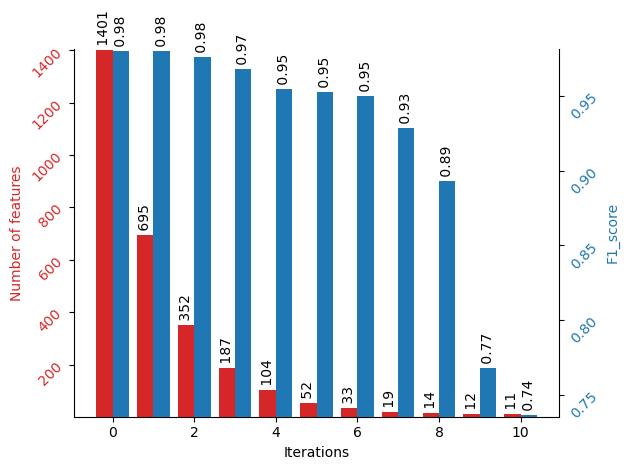

In [7]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=8000, shuffle=False,random_state=42)
iterarions,features,scores,stds = cafs(covering_array,X_cacao,y_cacao,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'../output_images/cacao_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [8]:
print("CAFS MLP - Cacao Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Cacao, Std: {std:.6f}")

CAFS MLP - Cacao Dataset
Index 0: Dataset Cacao, Std: 0.016435
Index 1: Dataset Cacao, Std: 0.019128
Index 2: Dataset Cacao, Std: 0.023003
Index 3: Dataset Cacao, Std: 0.024623
Index 4: Dataset Cacao, Std: 0.037206
Index 5: Dataset Cacao, Std: 0.031459
Index 6: Dataset Cacao, Std: 0.030536
Index 7: Dataset Cacao, Std: 0.038436
Index 8: Dataset Cacao, Std: 0.041091
Index 9: Dataset Cacao, Std: 0.078788
Index 10: Dataset Cacao, Std: 0.092818


best f1 score= 0.738993813344548, iteration:0, numbers features selected =13,best features selected=G, NIR, EXGR, NGRDI, GBRI, GBRI.1, VEG, DVI, EVI, REVI, NDRE, RERVI, REDVI
best f1 score= 0.740562171022209, iteration:1, numbers features selected =5,best features selected=G, GBRI, EVI, RERVI, REDVI
best f1 score= 0.7422493466601323, iteration:2, numbers features selected =3,best features selected=G, RERVI, REDVI
best f1 score= 0.7422493466601323, iteration:3, numbers features selected =3,best features selected=G, RERVI, REDVI
best f1 score= 0.7422493466601323, iteration:4, numbers features selected =3,best features selected=G, RERVI, REDVI
best f1 score= 0.7422493466601323, iteration:5, numbers features selected =3,best features selected=G, RERVI, REDVI
best f1 score= 0.7422493466601323, iteration:6, numbers features selected =3,best features selected=G, RERVI, REDVI
best f1 score= 0.7422493466601323, iteration:7, numbers features selected =3,best features selected=G, RERVI, REDVI
bes

<Figure size 1100x1000 with 0 Axes>

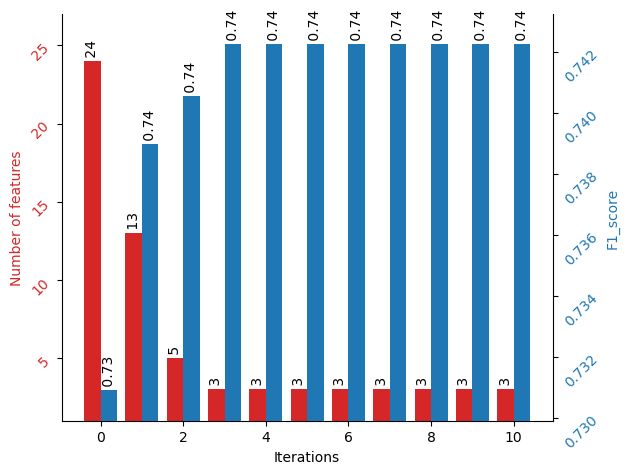

In [9]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False,random_state=42)
iterarions,features,scores,stds = cafs(covering_array,X_algarrobo,y_algarrobo,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'../output_images/algarrobo_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [10]:
print("CAFS MLP - Algarrobo Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Algarrobo, Std: {std:.6f}")

CAFS MLP - Algarrobo Dataset
Index 0: Dataset Algarrobo, Std: 0.058013
Index 1: Dataset Algarrobo, Std: 0.051547
Index 2: Dataset Algarrobo, Std: 0.051930
Index 3: Dataset Algarrobo, Std: 0.052756
Index 4: Dataset Algarrobo, Std: 0.052756
Index 5: Dataset Algarrobo, Std: 0.052756
Index 6: Dataset Algarrobo, Std: 0.052756
Index 7: Dataset Algarrobo, Std: 0.052756
Index 8: Dataset Algarrobo, Std: 0.052756
Index 9: Dataset Algarrobo, Std: 0.052756
Index 10: Dataset Algarrobo, Std: 0.052756


best f1 score= 0.954577404146387, iteration:0, numbers features selected =6,best features selected=X, Y, X10, X20, Y30, Y40
best f1 score= 0.955774627242716, iteration:1, numbers features selected =4,best features selected=X, Y, Y30, Y40
best f1 score= 0.955774627242716, iteration:2, numbers features selected =4,best features selected=X, Y, Y30, Y40
best f1 score= 0.955774627242716, iteration:3, numbers features selected =4,best features selected=X, Y, Y30, Y40
best f1 score= 0.955774627242716, iteration:4, numbers features selected =4,best features selected=X, Y, Y30, Y40
best f1 score= 0.955774627242716, iteration:5, numbers features selected =4,best features selected=X, Y, Y30, Y40
best f1 score= 0.955774627242716, iteration:6, numbers features selected =4,best features selected=X, Y, Y30, Y40
best f1 score= 0.955774627242716, iteration:7, numbers features selected =4,best features selected=X, Y, Y30, Y40
best f1 score= 0.955774627242716, iteration:8, numbers features selected =4,be

<Figure size 1100x1000 with 0 Axes>

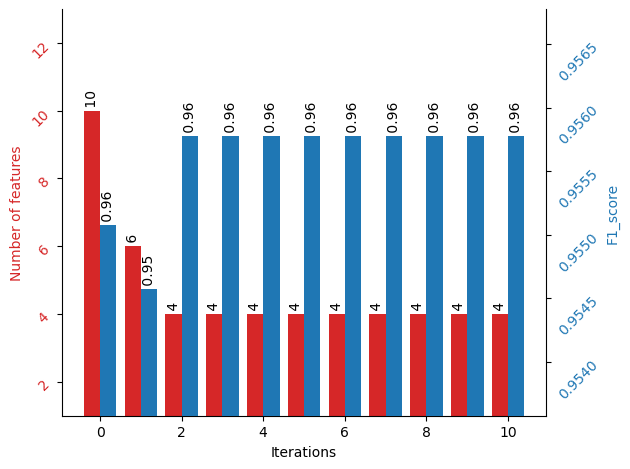

In [7]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False,random_state=42)
iterarions,features,scores,stds = cafs(covering_array,X_cis,y_cis,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'../output_images/cis_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [8]:
print("CAFS MLP - CIS Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset CIS, Std: {std:.6f}")

CAFS MLP - CIS Dataset
Index 0: Dataset CIS, Std: 0.002266
Index 1: Dataset CIS, Std: 0.002743
Index 2: Dataset CIS, Std: 0.003805
Index 3: Dataset CIS, Std: 0.003805
Index 4: Dataset CIS, Std: 0.003805
Index 5: Dataset CIS, Std: 0.003805
Index 6: Dataset CIS, Std: 0.003805
Index 7: Dataset CIS, Std: 0.003805
Index 8: Dataset CIS, Std: 0.003805
Index 9: Dataset CIS, Std: 0.003805
Index 10: Dataset CIS, Std: 0.003805


best f1 score= 0.9386932578174694, iteration:0, numbers features selected =128,best features selected=903.187, 910.907, 922.487, 926.347, 941.787, 953.367, 957.227, 961.087, 964.947, 968.807, 972.667, 976.527, 980.387, 984.247, 988.107, 995.827, 999.687, 1003.547, 1007.407, 1011.267, 1018.987, 1030.567, 1038.287, 1042.147, 1053.727, 1057.587, 1065.307, 1084.607, 1088.467, 1092.327, 1096.187, 1100.047, 1103.907, 1107.767, 1111.627, 1119.347, 1123.207, 1127.067, 1134.786, 1150.226, 1157.946, 1161.806, 1173.386, 1181.106, 1184.966, 1188.826, 1192.686, 1200.406, 1208.126, 1211.986, 1223.566, 1239.006, 1242.866, 1246.726, 1250.586, 1254.446, 1258.306, 1262.166, 1277.606, 1293.046, 1304.626, 1308.486, 1323.926, 1327.786, 1339.366, 1343.226, 1347.086, 1354.806, 1362.526, 1366.386, 1389.545, 1401.125, 1404.985, 1412.705, 1424.285, 1432.005, 1435.865, 1439.725, 1443.585, 1447.445, 1459.025, 1466.745, 1470.605, 1478.325, 1509.205, 1513.065, 1524.645, 1528.505, 1532.365, 1547.805, 1551.665, 1555.

<Figure size 1100x1000 with 0 Axes>

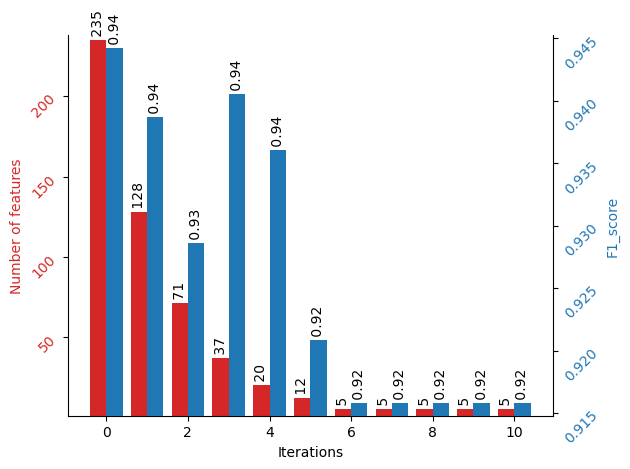

In [9]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False,random_state=42)
iterarions,features,scores,stds = cafs(covering_array,X_fruit_puree,y_fruit_puree,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'../output_images/fruit_pure_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [10]:
print("CAFS MLP - Fruit Puree Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Fruit Puree, Std: {std:.6f}")

CAFS MLP - Fruit Puree Dataset
Index 0: Dataset Fruit Puree, Std: 0.016470
Index 1: Dataset Fruit Puree, Std: 0.016589
Index 2: Dataset Fruit Puree, Std: 0.016445
Index 3: Dataset Fruit Puree, Std: 0.013271
Index 4: Dataset Fruit Puree, Std: 0.020588
Index 5: Dataset Fruit Puree, Std: 0.023848
Index 6: Dataset Fruit Puree, Std: 0.017616
Index 7: Dataset Fruit Puree, Std: 0.017616
Index 8: Dataset Fruit Puree, Std: 0.017616
Index 9: Dataset Fruit Puree, Std: 0.017616
Index 10: Dataset Fruit Puree, Std: 0.017616


best f1 score= 0.9916339869281046, iteration:0, numbers features selected =218,best features selected=1007.279, 1009.2085, 1013.0675, 1014.997, 1016.9265, 1018.856, 1020.7855, 1024.6445, 1028.5035, 1032.3625, 1034.292, 1040.0815, 1045.87, 1047.7995, 1055.5175, 1057.447, 1061.306, 1069.024, 1070.9535, 1072.883, 1078.6725, 1080.602, 1086.3905, 1090.2495, 1097.9675, 1099.897, 1101.8265, 1105.6855, 1107.615, 1115.334, 1121.1225, 1126.911, 1128.8405, 1132.7005, 1134.63, 1138.489, 1148.1365, 1151.9955, 1155.8545, 1161.643, 1165.502, 1167.4325, 1179.0095, 1180.939, 1188.657, 1192.517, 1194.4465, 1202.1645, 1206.0235, 1207.953, 1209.8825, 1215.671, 1217.6005, 1219.53, 1221.4595, 1223.389, 1227.249, 1231.108, 1233.0375, 1236.8965, 1240.7555, 1244.6145, 1246.544, 1248.4745, 1250.404, 1254.263, 1260.0515, 1265.84, 1267.7695, 1271.6285, 1273.558, 1277.417, 1279.3465, 1281.276, 1287.0655, 1294.7835, 1296.713, 1298.6425, 1302.5015, 1306.3615, 1308.291, 1314.0795, 1316.009, 1323.727, 1325.6565, 1327.

<Figure size 1100x1000 with 0 Axes>

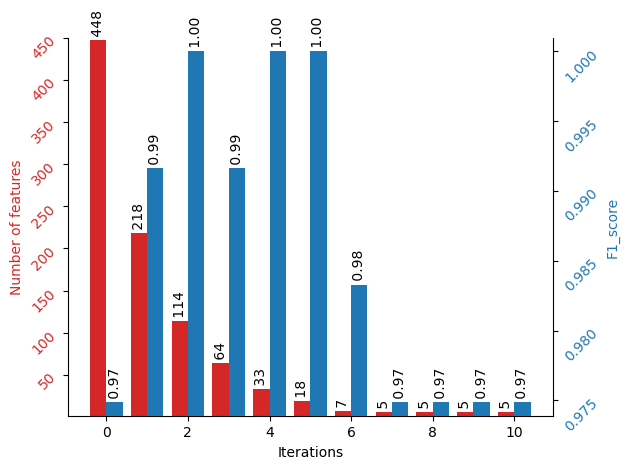

In [11]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False,random_state=42)
iterarions,features,scores,stds = cafs(covering_array,X_meat,y_meat,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'../output_images/meat_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [12]:
print("CAFS MLP - Meat Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Meat, Std: {std:.6f}")

CAFS MLP - Meat Dataset
Index 0: Dataset Meat, Std: 0.020492
Index 1: Dataset Meat, Std: 0.016732
Index 2: Dataset Meat, Std: 0.000000
Index 3: Dataset Meat, Std: 0.016732
Index 4: Dataset Meat, Std: 0.000000
Index 5: Dataset Meat, Std: 0.000000
Index 6: Dataset Meat, Std: 0.033399
Index 7: Dataset Meat, Std: 0.020492
Index 8: Dataset Meat, Std: 0.020492
Index 9: Dataset Meat, Std: 0.020492
Index 10: Dataset Meat, Std: 0.020492


best f1 score= 0.92739898989899, iteration:0, numbers features selected =271,best features selected=804.6805, 808.5395, 810.469, 814.328, 816.2575, 818.187, 827.8345, 829.764, 831.6935, 833.623, 835.5525, 845.2, 850.9885, 852.918, 858.7065, 866.4245, 868.354, 870.2835, 872.213, 876.072, 878.0015, 881.8605, 883.79, 885.7195, 887.649, 889.5785, 893.4375, 897.2965, 901.1555, 903.085, 908.8735, 914.662, 916.5915, 924.3095, 926.239, 930.098, 937.816, 939.7455, 941.675, 947.4645, 949.394, 955.1825, 959.0415, 966.7595, 968.689, 970.6185, 974.4775, 976.407, 984.125, 989.9135, 995.702, 997.6315, 1001.4905, 1003.42, 1007.279, 1016.9265, 1022.715, 1028.5035, 1032.3625, 1034.292, 1045.87, 1047.7995, 1055.5175, 1059.3765, 1061.306, 1069.024, 1072.883, 1074.8135, 1076.743, 1082.5315, 1084.461, 1086.3905, 1088.32, 1090.2495, 1096.038, 1099.897, 1101.8265, 1105.6855, 1109.5455, 1113.4045, 1115.334, 1117.2635, 1119.193, 1123.052, 1128.8405, 1134.63, 1136.5595, 1140.4185, 1142.348, 1144.2775, 1146.207, 

<Figure size 1100x1000 with 0 Axes>

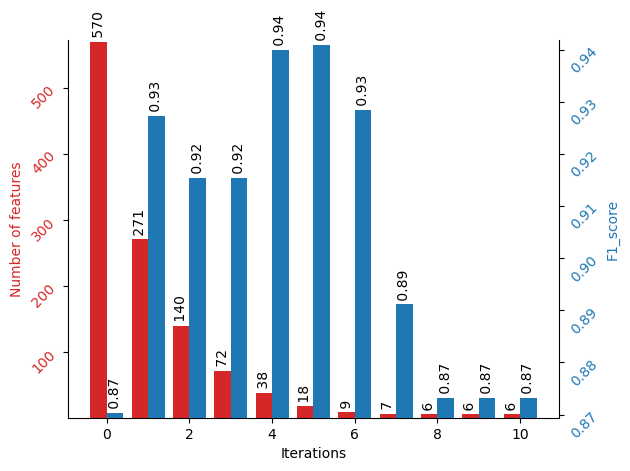

In [13]:
start_time = time.time()
lr_algo = MLPClassifier(solver="sgd", max_iter=7000, shuffle=False,random_state=42)
iterarions,features,scores,std = cafs(covering_array,X_olive,y_olive,10,lr_algo,True)
plot_results_for_covering_array(scores,features,iterarions, r'../output_images/olive_mlp_cafs.png')
end_time = time.time()
print(f"Processing time: {end_time - start_time} seconds")

In [14]:
print("CAFS MLP - Olive Dataset")
for i, std in enumerate(stds):
    print(f"Index {i}: Dataset Olive, Std: {std:.6f}")

CAFS MLP - Olive Dataset
Index 0: Dataset Olive, Std: 0.020492
Index 1: Dataset Olive, Std: 0.016732
Index 2: Dataset Olive, Std: 0.000000
Index 3: Dataset Olive, Std: 0.016732
Index 4: Dataset Olive, Std: 0.000000
Index 5: Dataset Olive, Std: 0.000000
Index 6: Dataset Olive, Std: 0.033399
Index 7: Dataset Olive, Std: 0.020492
Index 8: Dataset Olive, Std: 0.020492
Index 9: Dataset Olive, Std: 0.020492
Index 10: Dataset Olive, Std: 0.020492
